In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df=pd.read_csv("C:/Users/HP/Documents/Email-Classification-Analysis/data/SMSSpamCollection", sep="\t",
    header=None,
    names=["Category", "Email"]
)

df.head()

,Category,Email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape


(5572, 2)

In [6]:
df.columns

Index(['Category', 'Email'], dtype='str')

In [7]:
df["Category"].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Category    0
Email       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df[df.duplicated()].head()

,Category,Email
103,ham,As per your request 'Melle Melle (Oru Minnamin...
154,ham,As per your request 'Melle Melle (Oru Minnamin...
207,ham,"As I entered my cabin my PA said, '' Happy B'd..."
223,ham,"Sorry, I'll call later"
326,ham,No calls..messages..missed calls


In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(5169, 2)

In [13]:
df["Category"].value_counts()

Category
ham     4516
spam     653
Name: count, dtype: int64

In [14]:
df["Category"] = df["Category"].replace("ham", "Personal")

In [15]:
df["Category"].value_counts()

Category
Personal    4516
spam         653
Name: count, dtype: int64

In [16]:
df["Category"] = df["Category"].replace("spam", "Spam")

In [17]:
df["Category"].value_counts()

Category
Personal    4516
Spam         653
Name: count, dtype: int64

In [18]:
category_percentage = df["Category"].value_counts(normalize=True) * 100

category_percentage

Category
Personal    87.366996
Spam        12.633004
Name: proportion, dtype: float64

In [19]:
category_counts = df["Category"].value_counts()

category_counts

Category
Personal    4516
Spam         653
Name: count, dtype: int64

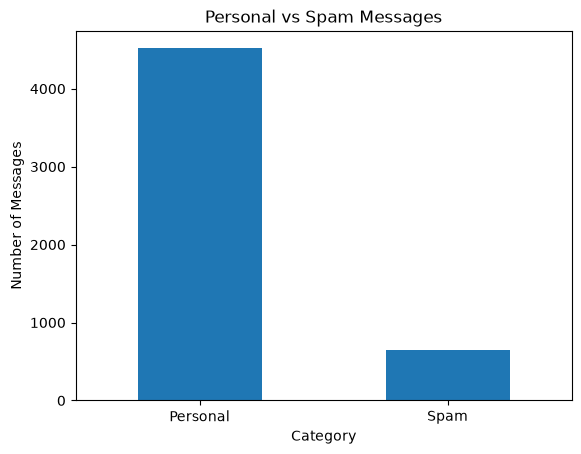

In [20]:
category_counts.plot(kind="bar")

plt.title("Personal vs Spam Messages")
plt.xlabel("Category")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()

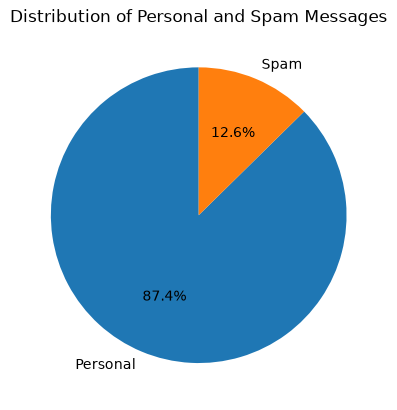

In [21]:
category_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Personal and Spam Messages")
plt.ylabel("")
plt.show()

In [22]:
df["Message_Length"] = df["Email"].str.len()

df.head()

,Category,Email,Message_Length
0,Personal,"Go until jurong point, crazy.. Available only ...",111
1,Personal,Ok lar... Joking wif u oni...,29
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,Personal,U dun say so early hor... U c already then say...,49
4,Personal,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
df["Message_Length"].describe()

count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: Message_Length, dtype: float64

In [24]:
df.groupby("Category")["Message_Length"].mean()

Category
Personal     70.905890
Spam        137.704441
Name: Message_Length, dtype: float64

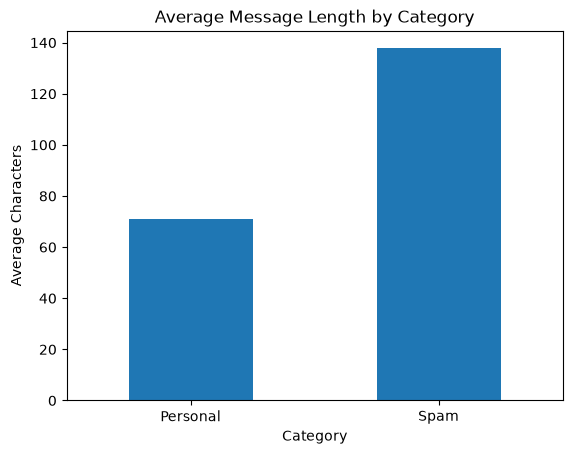

In [25]:
df.groupby("Category")["Message_Length"].mean().plot(kind="bar")

plt.title("Average Message Length by Category")
plt.xlabel("Category")
plt.ylabel("Average Characters")
plt.xticks(rotation=0)
plt.show()

In [26]:
df["Word_Count"] = df["Email"].str.split().str.len()

df.head()

,Category,Email,Message_Length,Word_Count
0,Personal,"Go until jurong point, crazy.. Available only ...",111,20
1,Personal,Ok lar... Joking wif u oni...,29,6
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,Personal,U dun say so early hor... U c already then say...,49,11
4,Personal,"Nah I don't think he goes to usf, he lives aro...",61,13


In [27]:
df["Word_Count"].describe()

count    5169.000000
mean       15.439930
std        11.117073
min         1.000000
25%         7.000000
50%        12.000000
75%        22.000000
max       171.000000
Name: Word_Count, dtype: float64

In [28]:
df.groupby("Category")["Word_Count"].mean()

Category
Personal    14.239814
Spam        23.739663
Name: Word_Count, dtype: float64

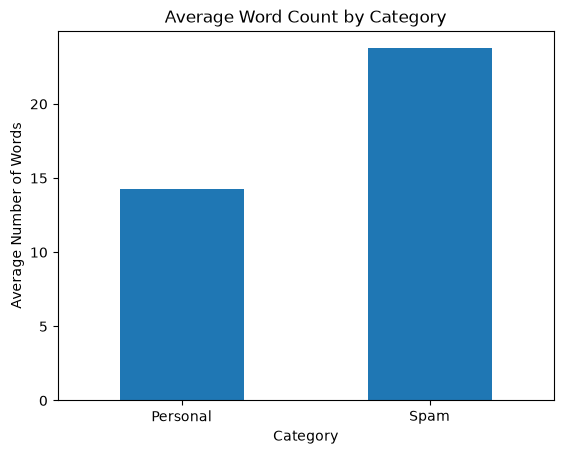

In [29]:
df.groupby("Category")["Word_Count"].mean().plot(kind="bar")

plt.title("Average Word Count by Category")
plt.xlabel("Category")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

In [30]:
all_text = " ".join(df["Email"])

len(all_text)

415300

In [31]:
words = all_text.lower().split()

len(words)

79809

In [32]:
from collections import Counter

word_counts = Counter(words)

word_counts.most_common(20)

[('i', 2102),
 ('to', 2065),
 ('you', 1836),
 ('a', 1295),
 ('the', 1235),
 ('and', 920),
 ('u', 897),
 ('in', 789),
 ('is', 773),
 ('my', 680),
 ('for', 659),
 ('your', 619),
 ('me', 585),
 ('of', 553),
 ('have', 535),
 ('on', 477),
 ('call', 470),
 ('are', 459),
 ('that', 455),
 ('it', 441)]

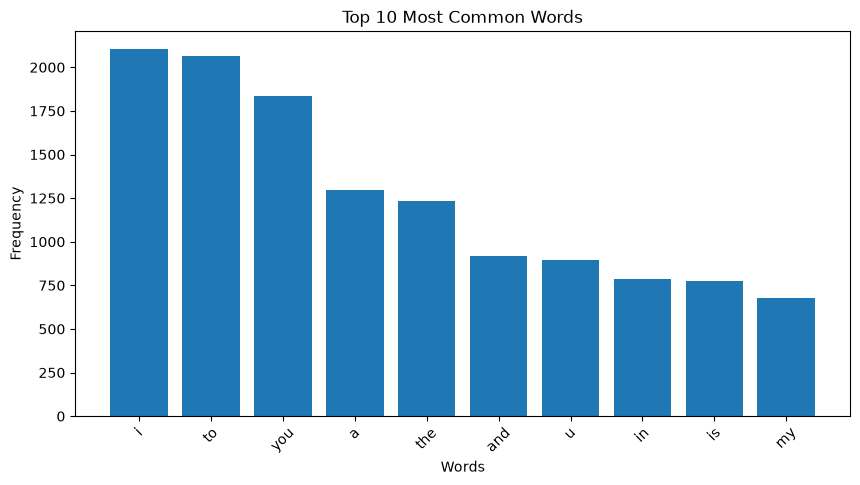

In [33]:
top_words = word_counts.most_common(10)

word_names = [word[0] for word in top_words]
word_values = [word[1] for word in top_words]

plt.figure(figsize=(10, 5))
plt.bar(word_names, word_values)

plt.title("Top 10 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [34]:
stop_words = {
    "the", "to", "and", "a", "of", "in", "is", "you", "for",
    "on", "it", "i", "this", "that", "are", "be", "with",
    "your", "have", "was", "my", "me", "we", "at", "so",
    "but", "do", "can", "or", "if", "not", "will"
}

In [35]:
filtered_words = [
    word for word in words
    if word not in stop_words
]

len(filtered_words)

58465

In [36]:
filtered_word_counts = Counter(filtered_words)

filtered_word_counts.most_common(20)

[('u', 897),
 ('call', 470),
 ('2', 427),
 ("i'm", 366),
 ('get', 353),
 ('just', 341),
 ('ur', 319),
 ('from', 264),
 ('up', 262),
 ('when', 262),
 ('go', 256),
 ('&lt;#&gt;', 254),
 ('how', 252),
 ('all', 242),
 ('what', 240),
 ('no', 239),
 ('4', 232),
 ('now', 229),
 ('got', 228),
 ('like', 226)]

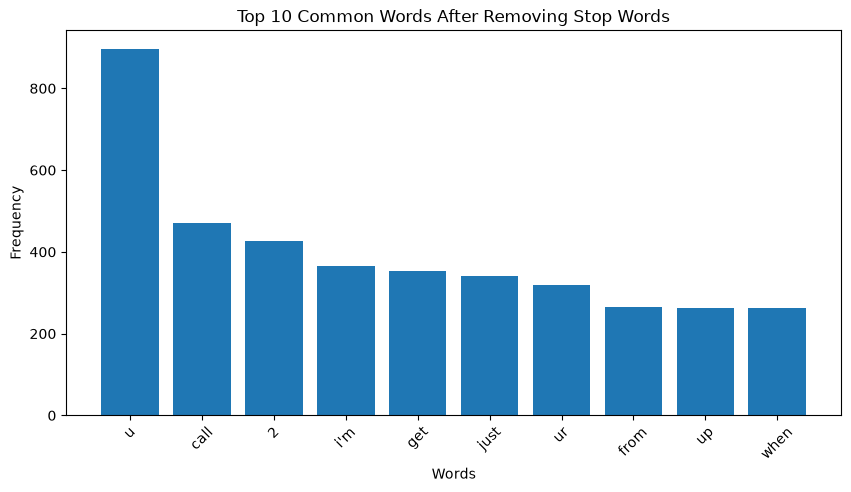

In [37]:
top_words = filtered_word_counts.most_common(10)

word_names = [word[0] for word in top_words]
word_values = [word[1] for word in top_words]

plt.figure(figsize=(10, 5))
plt.bar(word_names, word_values)

plt.title("Top 10 Common Words After Removing Stop Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [38]:
spam_text = " ".join(df[df["Category"] == "Spam"]["Email"])

spam_words = spam_text.lower().split()

len(spam_words)

15502

In [39]:
spam_filtered_words = [
    word for word in spam_words
    if word not in stop_words
]

spam_word_counts = Counter(spam_filtered_words)

spam_word_counts.most_common(15)

[('call', 298),
 ('free', 157),
 ('2', 151),
 ('ur', 119),
 ('from', 118),
 ('txt', 114),
 ('text', 96),
 ('u', 96),
 ('mobile', 95),
 ('reply', 93),
 ('claim', 89),
 ('&', 89),
 ('stop', 84),
 ('now', 79),
 ('our', 77)]

In [40]:
personal_text = " ".join(df[df["Category"] == "Personal"]["Email"])

personal_words = personal_text.lower().split()

personal_filtered_words = [
    word for word in personal_words
    if word not in stop_words
]

personal_word_counts = Counter(personal_filtered_words)

personal_word_counts.most_common(15)

[('u', 801),
 ("i'm", 358),
 ('get', 285),
 ('2', 276),
 ('just', 274),
 ('&lt;#&gt;', 254),
 ('when', 251),
 ('how', 244),
 ('up', 244),
 ('go', 230),
 ('what', 228),
 ('got', 222),
 ('all', 217),
 ('like', 214),
 ('no', 210)]

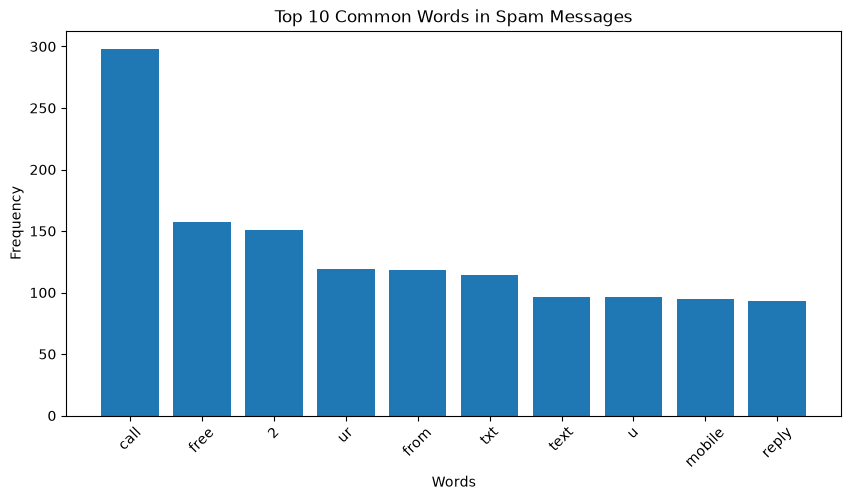

In [41]:
top_spam_words = spam_word_counts.most_common(10)

spam_names = [word[0] for word in top_spam_words]
spam_values = [word[1] for word in top_spam_words]

plt.figure(figsize=(10, 5))
plt.bar(spam_names, spam_values)

plt.title("Top 10 Common Words in Spam Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

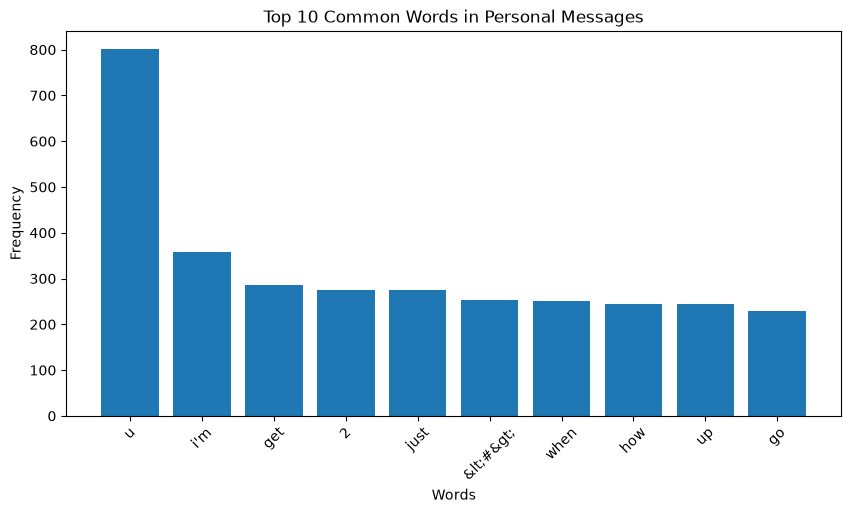

In [42]:
top_personal_words = personal_word_counts.most_common(10)

personal_names = [word[0] for word in top_personal_words]
personal_values = [word[1] for word in top_personal_words]

plt.figure(figsize=(10, 5))
plt.bar(personal_names, personal_values)

plt.title("Top 10 Common Words in Personal Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [43]:
length_comparison = df.groupby("Category").agg(
    Average_Message_Length=("Message_Length", "mean"),
    Average_Word_Count=("Word_Count", "mean")
)

length_comparison

,Average_Message_Length,Average_Word_Count
Category,,
Personal,70.905890,14.239814
Spam,137.704441,23.739663


In [44]:
summary = df["Category"].value_counts().reset_index()

summary.columns = ["Category", "Message_Count"]

summary["Percentage"] = (
    summary["Message_Count"] / summary["Message_Count"].sum() * 100
).round(2)

summary

,Category,Message_Count,Percentage
0,Personal,4516,87.37
1,Spam,653,12.63


In [45]:
import os

os.getcwd()

'C:\\Users\\HP'

In [46]:
os.listdir()

['.anaconda',
 '.cache',
 '.conda',
 '.continuum',
 '.copilot',
 '.git-for-windows-updater',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.lesshst',
 '.matplotlib',
 '.spyder-py3',
 '.streamlit',
 '.vscode',
 '.vscode-shared',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Email_Classification_Analysis.ipynb',
 'Email_Classification_Analysis.ipynb.ipynb',
 'Favorites',
 'jupyter_runtime',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{878542de-2ad1-11f1-b4b8-4ca9549e7865}.TM.blf',
 'NTUSER.DAT{878542de-2ad1-11f1-b4b8-4ca9549e7865}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{878542de-2ad1-11f1-b4b8-4ca9549e7865}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'PycharmProjects',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 '

In [47]:
import os

os.makedirs(
    r"C:\Users\HP\Documents\Email-Classification-Analysis\output",
    exist_ok=True
)


In [53]:
os.listdir(
    r"C:\Users\HP\Documents\Email-Classification-Analysis\output"
)

['.ipynb_checkpoints', 'cleaned_email_data.csv']

In [50]:
os.listdir(
    r"C:\Users\HP\Documents\Email-Classification-Analysis\output"
)

['.ipynb_checkpoints', 'cleaned_email_data.csv']

In [51]:
output_path = r"C:\Users\HP\Documents\Email-Classification-Analysis\output\cleaned_email_data.csv"

df.to_csv(output_path, index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [52]:
test_df = pd.read_csv(output_path)

print("Shape:", test_df.shape)
test_df.head()

Shape: (5169, 4)


,Category,Email,Message_Length,Word_Count
0,Personal,"Go until jurong point, crazy.. Available only ...",111,20
1,Personal,Ok lar... Joking wif u oni...,29,6
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,Personal,U dun say so early hor... U c already then say...,49,11
4,Personal,"Nah I don't think he goes to usf, he lives aro...",61,13


In [55]:
print(test_df["Category"].value_counts())

Category
Personal    4516
Spam         653
Name: count, dtype: int64
